In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the feature-engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_gold.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort data chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Display first 5 rows
df.head()

,Date,Price,Daily_Return,MA_7,MA_30,Volatility_30,Is_Anomaly,Year,Month,Price_Range,Momentum_7,Price_Lag_1,Price_Lag_7,Price_Lag_30,Price_vs_MA30,MA_90
0,2011-01-01,2069,NaN,NaN,NaN,NaN,False,2011,1,1482,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-02,2069,0.000000,NaN,NaN,NaN,False,2011,1,1482,NaN,2069.0,NaN,NaN,NaN,NaN
2,2011-01-03,2076,0.338328,NaN,NaN,NaN,False,2011,1,1482,NaN,2069.0,NaN,NaN,NaN,NaN
3,2011-01-04,2076,0.000000,NaN,NaN,NaN,False,2011,1,1482,NaN,2076.0,NaN,NaN,NaN,NaN
4,2011-01-05,2049,-1.300578,NaN,NaN,NaN,True,2011,1,1482,NaN,2076.0,NaN,NaN,NaN,NaN


In [3]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2873, 16)

Columns:
['Date', 'Price', 'Daily_Return', 'MA_7', 'MA_30', 'Volatility_30', 'Is_Anomaly', 'Year', 'Month', 'Price_Range', 'Momentum_7', 'Price_Lag_1', 'Price_Lag_7', 'Price_Lag_30', 'Price_vs_MA30', 'MA_90']

Data types:
Date             datetime64[ns]
Price                     int64
Daily_Return            float64
MA_7                    float64
MA_30                   float64
Volatility_30           float64
Is_Anomaly                 bool
Year                      int64
Month                     int64
Price_Range               int64
Momentum_7              float64
Price_Lag_1             float64
Price_Lag_7             float64
Price_Lag_30            float64
Price_vs_MA30           float64
MA_90                   float64
dtype: object

Missing values:
Date              0
Price             0
Daily_Return      1
MA_7              6
MA_30            29
Volatility_30    30
Is_Anomaly        0
Year              0
Month             0
Price_Range       0
Momentum

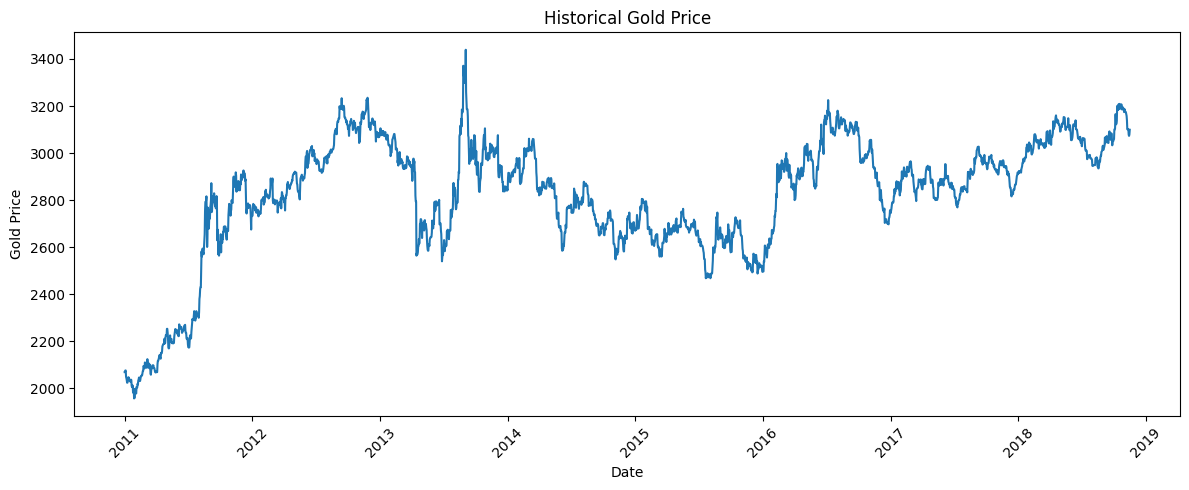

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Price"])

plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.title("Historical Gold Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Leakage-free ML feature preparation

lagged_features = [
    "Daily_Return",
    "MA_7",
    "MA_30",
    "Volatility_30",
    "Momentum_7",
    "Price_Lag_1",
    "Price_Lag_7",
    "Price_Lag_30",
    "Price_vs_MA30",
    "MA_90"
]

non_lagged_features = [
    "Year",
    "Month"
]

ml_data = df[
    ["Date"] + lagged_features + non_lagged_features + ["Price"]
].copy()

# Shift price-based features by one day
for column in lagged_features:
    ml_data[column] = ml_data[column].shift(1)

# Remove missing rows
ml_data = ml_data.dropna().reset_index(drop=True)

features = lagged_features + non_lagged_features

target = "Price"

X = ml_data[features]
y = ml_data[target]

print("Leakage-free ML data prepared!")
print("Rows:", len(ml_data))
print("Features:", len(features))
print("Missing values:", X.isnull().sum().sum())

Leakage-free ML data prepared!
Rows: 2783
Features: 12
Missing values: 0


In [22]:
split_index = int(len(ml_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

print("\nTraining period:")
print(
    ml_data["Date"].iloc[0],
    "to",
    ml_data["Date"].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    ml_data["Date"].iloc[split_index],
    "to",
    ml_data["Date"].iloc[-1]
)

Training data: 2226
Testing data: 557

Training period:
2011-04-01 00:00:00 to 2017-05-08 00:00:00

Testing period:
2017-05-09 00:00:00 to 2018-11-16 00:00:00


In [10]:
split_index = int(len(ml_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

print("\nTraining period:")
print(ml_data["Date"].iloc[0], "to", ml_data["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(ml_data["Date"].iloc[split_index], "to", ml_data["Date"].iloc[-1])

Training data: 2227
Testing data: 557

Training period:
2011-03-31 00:00:00 to 2017-05-08 00:00:00

Testing period:
2017-05-09 00:00:00 to 2018-11-16 00:00:00


In [23]:
linear_model = LinearRegression()

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

print("All models created successfully!")

All models created successfully!


In [24]:
linear_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

gradient_boosting_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [25]:
linear_predictions = linear_model.predict(X_test)

random_forest_predictions = random_forest_model.predict(X_test)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [26]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return mae, rmse, r2


linear_mae, linear_rmse, linear_r2 = evaluate_model(
    y_test, linear_predictions
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test, random_forest_predictions
)

gb_mae, gb_rmse, gb_r2 = evaluate_model(
    y_test, gradient_boosting_predictions
)


print("MODEL EVALUATION")
print("=" * 50)

print("\nLinear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

print("\nGradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

MODEL EVALUATION

Linear Regression
MAE : 9.90703817579445
RMSE: 14.316210978509622
R²  : 0.9802574454474086

Random Forest
MAE : 13.915906642728897
RMSE: 18.334115329603716
R²  : 0.9676207276597993

Gradient Boosting
MAE : 13.168820384268729
RMSE: 17.832206714657147
R²  : 0.9693692700364522


In [27]:
# Create final ML evaluation table

evaluation_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

evaluation_results

,Model,MAE,RMSE,R2
0,Linear Regression,9.907038,14.316211,0.980257
1,Random Forest,13.915907,18.334115,0.967621
2,Gradient Boosting,13.168820,17.832207,0.969369


In [28]:
# Make sure the results folders exist

os.makedirs("../results/ml", exist_ok=True)
os.makedirs("../results/forecasting", exist_ok=True)
os.makedirs("../results/graphs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Save evaluation results

evaluation_results.to_csv(
    "../results/ml/model_evaluation.csv",
    index=False
)

print("Model evaluation saved successfully!")

Model evaluation saved successfully!


In [29]:
# Create final predictions table

predictions_df = pd.DataFrame({
    "Date": ml_data["Date"].iloc[split_index:].values,
    "Actual_Price": y_test.values,
    "Linear_Regression": linear_predictions,
    "Random_Forest": random_forest_predictions,
    "Gradient_Boosting": gradient_boosting_predictions
})

predictions_df.head()

,Date,Actual_Price,Linear_Regression,Random_Forest,Gradient_Boosting
0,2017-05-09,2800,2808.642809,2811.88,2810.401778
1,2017-05-10,2805,2799.425369,2815.74,2803.539799
2,2017-05-11,2806,2804.010620,2793.78,2796.551237
3,2017-05-12,2807,2805.733970,2810.69,2810.674392
4,2017-05-13,2801,2806.672368,2810.97,2810.674392


In [30]:
predictions_df.to_csv(
    "../results/ml/predictions_all_models.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [31]:
# Save the corrected trained models

joblib.dump(
    linear_model,
    "../models/linear_regression.joblib"
)

joblib.dump(
    random_forest_model,
    "../models/random_forest.joblib"
)

joblib.dump(
    gradient_boosting_model,
    "../models/gradient_boosting.joblib"
)

print("Corrected ML models saved successfully!")

Corrected ML models saved successfully!


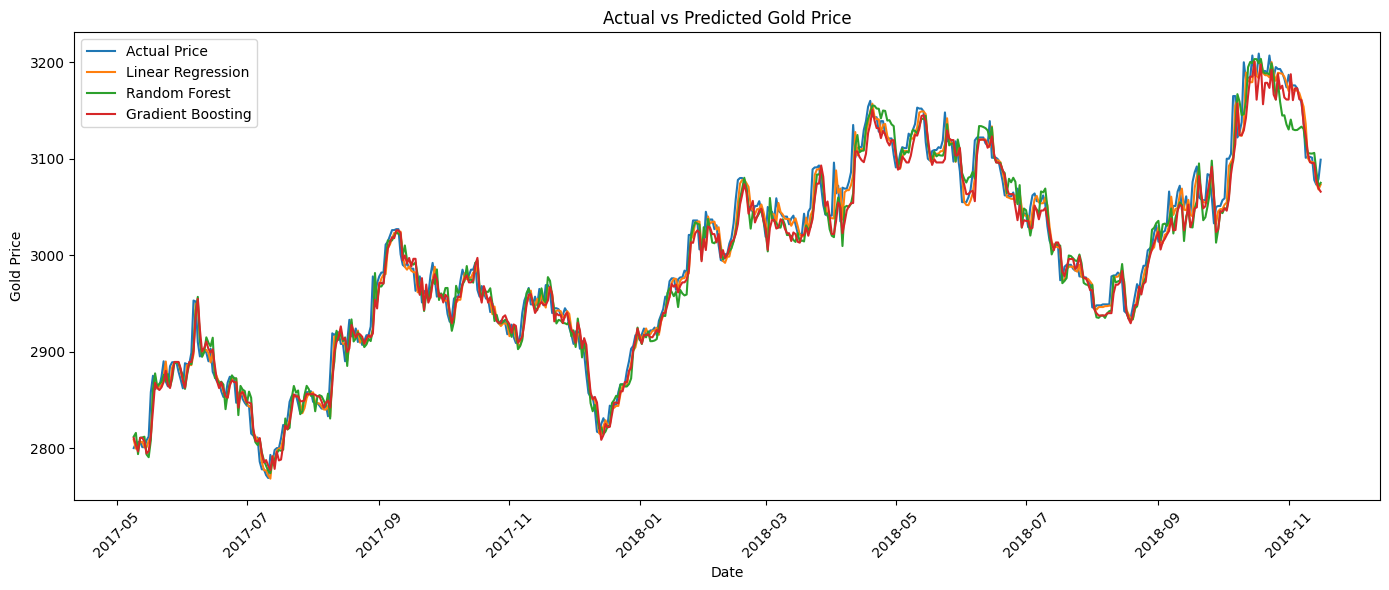

Actual vs Predicted graph saved successfully!


In [32]:
# ============================================================
# ACTUAL VS PREDICTED GOLD PRICE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    predictions_df["Date"],
    predictions_df["Actual_Price"],
    label="Actual Price"
)

plt.plot(
    predictions_df["Date"],
    predictions_df["Linear_Regression"],
    label="Linear Regression"
)

plt.plot(
    predictions_df["Date"],
    predictions_df["Random_Forest"],
    label="Random Forest"
)

plt.plot(
    predictions_df["Date"],
    predictions_df["Gradient_Boosting"],
    label="Gradient Boosting"
)

plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.title("Actual vs Predicted Gold Price")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../results/graphs/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Actual vs Predicted graph saved successfully!")

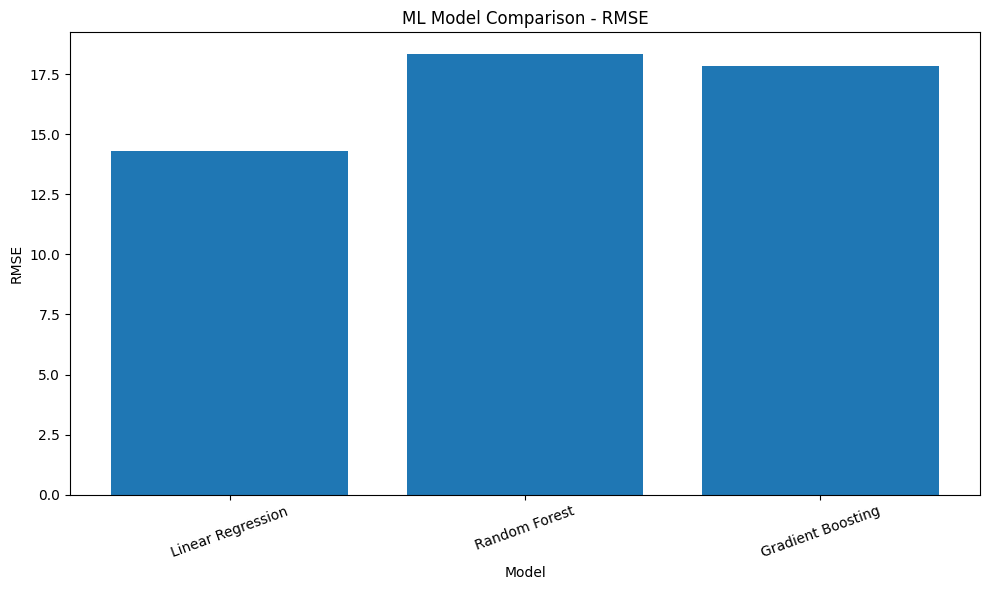

Model comparison graph saved successfully!


In [33]:
# ============================================================
# MODEL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    evaluation_results["Model"],
    evaluation_results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("ML Model Comparison - RMSE")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../results/graphs/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Model comparison graph saved successfully!")

In [34]:
# ============================================================
# ARIMA - PREPARE TIME SERIES DATA
# ============================================================

# Create a copy of Date and Price
ts_data = df[["Date", "Price"]].copy()

# Sort by date
ts_data = ts_data.sort_values("Date").reset_index(drop=True)

# Set Date as the index
ts_data = ts_data.set_index("Date")

print("Time-series data:")
print(ts_data.head())

print("\nTime-series shape:", ts_data.shape)

print("\nDate range:")
print(ts_data.index.min(), "to", ts_data.index.max())

Time-series data:
            Price
Date             
2011-01-01   2069
2011-01-02   2069
2011-01-03   2076
2011-01-04   2076
2011-01-05   2049

Time-series shape: (2873, 1)

Date range:
2011-01-01 00:00:00 to 2018-11-16 00:00:00


In [35]:
# Check for missing price values

print("Missing Price values:", ts_data["Price"].isnull().sum())

Missing Price values: 0


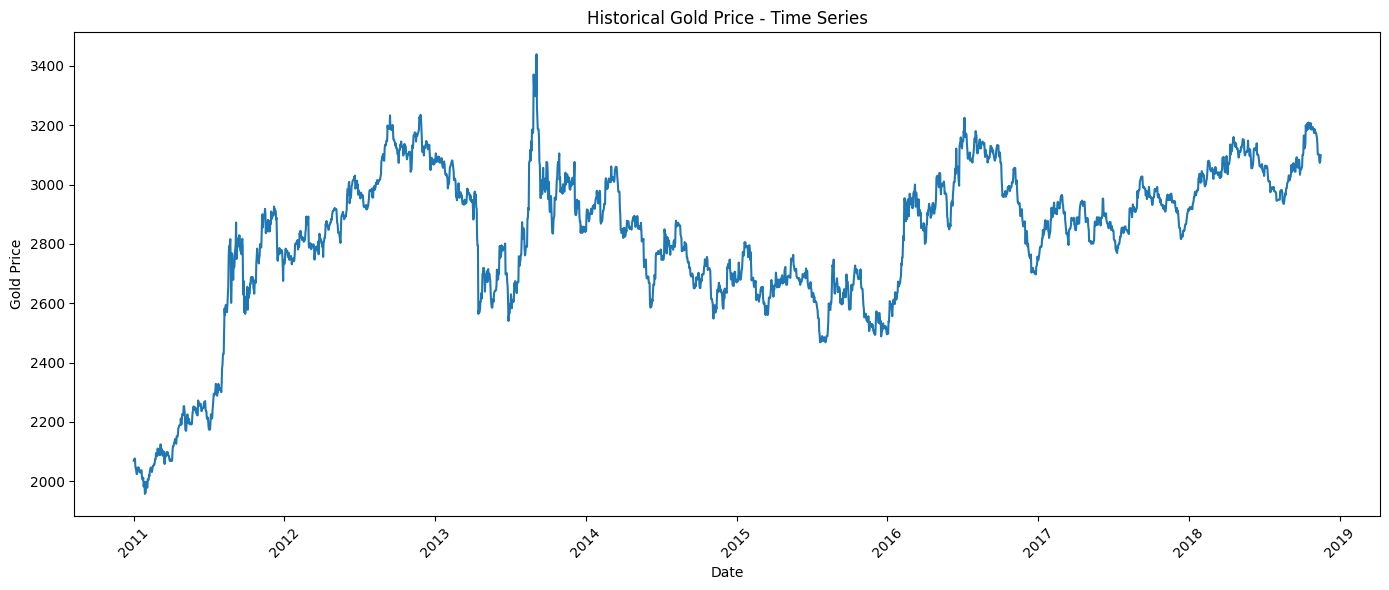

In [36]:
# Plot historical gold price for time-series analysis

plt.figure(figsize=(14, 6))

plt.plot(ts_data.index, ts_data["Price"])

plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.title("Historical Gold Price - Time Series")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [37]:
# ============================================================
# ARIMA TRAIN / TEST SPLIT
# ============================================================

ts_split_index = int(len(ts_data) * 0.80)

train_ts = ts_data["Price"].iloc[:ts_split_index]

test_ts = ts_data["Price"].iloc[ts_split_index:]

print("Training observations:", len(train_ts))
print("Testing observations:", len(test_ts))

print("\nTraining period:")
print(train_ts.index.min(), "to", train_ts.index.max())

print("\nTesting period:")
print(test_ts.index.min(), "to", test_ts.index.max())

Training observations: 2298
Testing observations: 575

Training period:
2011-01-01 00:00:00 to 2017-04-20 00:00:00

Testing period:
2017-04-21 00:00:00 to 2018-11-16 00:00:00


In [38]:
# ============================================================
# AUGMENTED DICKEY-FULLER (ADF) TEST
# ============================================================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_ts.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -3.1106109618053073
p-value: 0.02577783056757992

Critical Values:
1%: -3.433215059686721
5%: -2.862805715808642
10%: -2.5674437983902245


C:\Users\niraj\AppData\Local\Temp\ipykernel_76864\3321462939.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(train_ts.dropna())


In [39]:
# ============================================================
# ARIMA ORDER SELECTION USING AIC
# ============================================================

import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Since the ADF test indicates stationarity:
d = 0

# Candidate p and q values
p_values = range(0, 4)
q_values = range(0, 4)

arima_results = []

for p in p_values:
    for q in q_values:

        try:
            model = ARIMA(
                train_ts,
                order=(p, d, q)
            )

            fitted_model = model.fit()

            arima_results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fitted_model.aic
            })

        except Exception:
            pass

arima_results_df = pd.DataFrame(arima_results)

arima_results_df = arima_results_df.sort_values(
    "AIC"
).reset_index(drop=True)

print("ARIMA models ranked by AIC:")
print(arima_results_df)

ARIMA models ranked by AIC:
    p  d  q           AIC
0   1  0  1  21125.395418
1   2  0  0  21125.453063
2   3  0  1  21126.012660
3   1  0  0  21126.273775
4   2  0  3  21127.131786
5   3  0  0  21127.162659
6   1  0  2  21127.227241
7   2  0  1  21127.381480
8   3  0  3  21127.493264
9   1  0  3  21128.344679
10  2  0  2  21128.836173
11  3  0  2  21130.834822
12  0  0  3  25712.323403
13  0  0  2  27148.201428
14  0  0  1  29268.895007
15  0  0  0  32177.858230


In [43]:
# ============================================================
# FIT ARIMA(1,0,1) - FIXED INDEX VERSION
# ============================================================

arima_order = (1, 0, 1)

# Use a simple integer index for Statsmodels
train_values = train_ts.reset_index(drop=True)

arima_model = ARIMA(
    train_values,
    order=arima_order
)

arima_fitted = arima_model.fit()

print("ARIMA(1,0,1) fitted successfully!")
print("Number of training observations:", len(train_values))

ARIMA(1,0,1) fitted successfully!
Number of training observations: 2298


In [44]:
# ============================================================
# ARIMA FORECAST - FIXED
# ============================================================

# Forecast the same number of observations as the test set
arima_forecast_values = arima_fitted.forecast(
    steps=len(test_ts)
)

# Convert forecast to a Series
# and attach the actual test dates
arima_forecast = pd.Series(
    np.asarray(arima_forecast_values),
    index=test_ts.index,
    name="ARIMA_Forecast"
)

print("ARIMA forecast generated successfully!")

print("\nFirst 10 forecast values:")
print(arima_forecast.head(10))

print("\nForecast observations:", len(arima_forecast))
print("Test observations:", len(test_ts))

ARIMA forecast generated successfully!

First 10 forecast values:
Date
2017-04-21    2930.470030
2017-04-22    2930.047685
2017-04-23    2929.626505
2017-04-24    2929.206486
2017-04-25    2928.787626
2017-04-26    2928.369921
2017-04-27    2927.953367
2017-04-28    2927.537962
2017-04-29    2927.123703
2017-04-30    2926.710586
Name: ARIMA_Forecast, dtype: float64

Forecast observations: 575
Test observations: 575


In [45]:
# ============================================================
# ARIMA EVALUATION
# ============================================================

arima_mae = mean_absolute_error(
    test_ts,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        arima_forecast
    )
)

arima_r2 = r2_score(
    test_ts,
    arima_forecast
)

print("ARIMA MODEL EVALUATION")
print("=" * 40)

print("Model: ARIMA(1,0,1)")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("R²  :", arima_r2)

ARIMA MODEL EVALUATION
Model: ARIMA(1,0,1)
MAE : 157.50981130039122
RMSE: 188.31694385092922
R²  : -2.3538375656879946


In [46]:
# ============================================================
# SARIMA - CHECK SEASONAL PATTERN
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("Training observations:", len(train_ts))
print("Testing observations:", len(test_ts))

print("\nTesting possible seasonal periods:")
print("7  = approximately weekly")
print("12 = approximately monthly")
print("30 = approximately 30 observations")

Training observations: 2298
Testing observations: 575

Testing possible seasonal periods:
7  = approximately weekly
12 = approximately monthly
30 = approximately 30 observations


In [47]:
# ============================================================
# SARIMA - TEST SEASONAL PERIODS
# ============================================================

import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Use integer index for the irregularly spaced observations
train_values = train_ts.reset_index(drop=True)

# Non-seasonal order selected earlier
order = (1, 0, 1)

# Seasonal periods to test
seasonal_periods = [7, 12, 30]

sarima_results = []

for seasonal_period in seasonal_periods:

    try:
        print(f"Testing SARIMA seasonal period = {seasonal_period}...")

        model = SARIMAX(
            train_values,
            order=order,
            seasonal_order=(1, 0, 1, seasonal_period),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        sarima_results.append({
            "Seasonal_Period": seasonal_period,
            "AIC": fitted_model.aic
        })

        print(
            f"Completed: s={seasonal_period}, "
            f"AIC={fitted_model.aic:.2f}"
        )

    except Exception as e:

        print(
            f"Could not fit seasonal period {seasonal_period}: "
            f"{e}"
        )

sarima_results_df = pd.DataFrame(sarima_results)

sarima_results_df = sarima_results_df.sort_values(
    "AIC"
).reset_index(drop=True)

print("\nSARIMA models ranked by AIC:")
print(sarima_results_df)

Testing SARIMA seasonal period = 7...
Completed: s=7, AIC=21048.15
Testing SARIMA seasonal period = 12...
Completed: s=12, AIC=21016.21
Testing SARIMA seasonal period = 30...
Completed: s=30, AIC=20870.71

SARIMA models ranked by AIC:
   Seasonal_Period           AIC
0               30  20870.707377
1               12  21016.208317
2                7  21048.152901


In [48]:
# ============================================================
# FIT SARIMA MODEL
# ============================================================

sarima_order = (1, 0, 1)
sarima_seasonal_order = (1, 0, 1, 30)

# Use integer index because our dates are irregular
train_values = train_ts.reset_index(drop=True)

sarima_model = SARIMAX(
    train_values,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fitted = sarima_model.fit(disp=False)

print("SARIMA model fitted successfully!")

print("Model:")
print("SARIMA(1,0,1)(1,0,1,30)")

SARIMA model fitted successfully!
Model:
SARIMA(1,0,1)(1,0,1,30)


In [49]:
# ============================================================
# SARIMA FORECAST
# ============================================================

sarima_forecast_values = sarima_fitted.forecast(
    steps=len(test_ts)
)

# Attach the actual test dates
sarima_forecast = pd.Series(
    np.asarray(sarima_forecast_values),
    index=test_ts.index,
    name="SARIMA_Forecast"
)

print("SARIMA forecast generated successfully!")

print("\nFirst 10 forecast values:")
print(sarima_forecast.head(10))

print("\nForecast observations:", len(sarima_forecast))
print("Test observations:", len(test_ts))

SARIMA forecast generated successfully!

First 10 forecast values:
Date
2017-04-21    2931.223360
2017-04-22    2931.402067
2017-04-23    2931.649558
2017-04-24    2931.891118
2017-04-25    2932.097333
2017-04-26    2932.372240
2017-04-27    2932.602361
2017-04-28    2932.789732
2017-04-29    2933.006413
2017-04-30    2933.122457
Name: SARIMA_Forecast, dtype: float64

Forecast observations: 575
Test observations: 575


In [50]:
# ============================================================
# SARIMA EVALUATION
# ============================================================

sarima_mae = mean_absolute_error(
    test_ts,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        sarima_forecast
    )
)

sarima_r2 = r2_score(
    test_ts,
    sarima_forecast
)

print("SARIMA MODEL EVALUATION")
print("=" * 40)

print("Model: SARIMA(1,0,1)(1,0,1,30)")
print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("R²  :", sarima_r2)

SARIMA MODEL EVALUATION
Model: SARIMA(1,0,1)(1,0,1,30)
MAE : 63.57228231577966
RMSE: 76.58884456885183
R²  : 0.4452538902543052


In [51]:
# ============================================================
# CREATE FINAL FORECAST DATA
# ============================================================

forecast_df = pd.DataFrame({
    "Date": test_ts.index,
    "Actual_Price": test_ts.values,
    "ARIMA_Forecast": arima_forecast.values,
    "SARIMA_Forecast": sarima_forecast.values
})

print(forecast_df.head())

print("\nForecast data shape:", forecast_df.shape)

        Date  Actual_Price  ARIMA_Forecast  SARIMA_Forecast
0 2017-04-21          2938     2930.470030      2931.223360
1 2017-04-22          2942     2930.047685      2931.402067
2 2017-04-23          2942     2929.626505      2931.649558
3 2017-04-24          2908     2929.206486      2931.891118
4 2017-04-25          2891     2928.787626      2932.097333

Forecast data shape: (575, 4)


In [52]:
# ============================================================
# SAVE FORECAST CSV
# ============================================================

forecast_df.to_csv(
    "../results/forecasting/forecast.csv",
    index=False
)

print("Forecast CSV saved successfully!")

Forecast CSV saved successfully!


In [53]:
# ============================================================
# FORECASTING MODEL EVALUATION
# ============================================================

forecast_evaluation = pd.DataFrame({
    "Model": [
        "ARIMA(1,0,1)",
        "SARIMA(1,0,1)(1,0,1,30)"
    ],
    "MAE": [
        arima_mae,
        sarima_mae
    ],
    "RMSE": [
        arima_rmse,
        sarima_rmse
    ],
    "R2": [
        arima_r2,
        sarima_r2
    ]
})

print(forecast_evaluation)

                     Model         MAE        RMSE        R2
0             ARIMA(1,0,1)  157.509811  188.316944 -2.353838
1  SARIMA(1,0,1)(1,0,1,30)   63.572282   76.588845  0.445254


In [54]:
# Save forecasting evaluation

forecast_evaluation.to_csv(
    "../results/forecasting/forecast_evaluation.csv",
    index=False
)

print("Forecast evaluation saved successfully!")

Forecast evaluation saved successfully!


In [55]:
# ============================================================
# SAVE TIME-SERIES MODELS
# ============================================================

joblib.dump(
    arima_fitted,
    "../models/arima_1_0_1.joblib"
)

joblib.dump(
    sarima_fitted,
    "../models/sarima_1_0_1_1_0_1_30.joblib"
)

print("ARIMA and SARIMA models saved successfully!")

ARIMA and SARIMA models saved successfully!


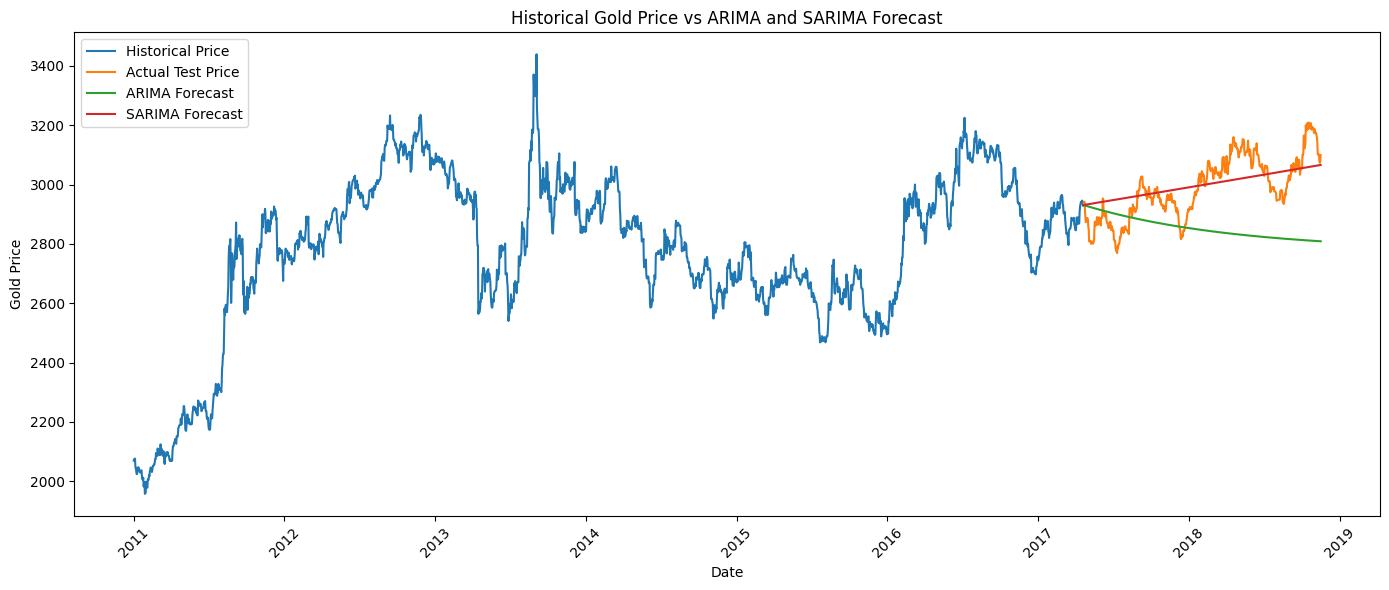

Historical vs Forecast graph saved successfully!


In [56]:
# ============================================================
# HISTORICAL VS FORECAST
# ============================================================

plt.figure(figsize=(14, 6))

# Plot the historical training data
plt.plot(
    train_ts.index,
    train_ts.values,
    label="Historical Price"
)

# Plot actual test prices
plt.plot(
    test_ts.index,
    test_ts.values,
    label="Actual Test Price"
)

# Plot ARIMA forecast
plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

# Plot SARIMA forecast
plt.plot(
    sarima_forecast.index,
    sarima_forecast.values,
    label="SARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Gold Price")

plt.title(
    "Historical Gold Price vs ARIMA and SARIMA Forecast"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../results/graphs/historical_vs_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Historical vs Forecast graph saved successfully!")